# Modeling Baseline

##  1. Objetivo

Construir um modelo baseline simples para servir como referência inicial na previsão de demanda.

O baseline permite validar o pipeline de modelagem e estabelecer uma métrica mínima de desempenho que deverá ser superada pelos modelos mais avançados.

Neste notebook será utilizado o modelo do tipo **Naive Forecast**, onde:

👉 previsão = valor observado no período anterior

## 2. Importação 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from IPython.display import Markdown
from IPython.core.display import HTML
import math

import glob
import warnings
warnings.filterwarnings('ignore')

## 3. Configuração Inicial

In [4]:
# Cor principal do projeto
PRIMARY_COLOR = "#50e550"
SECONDARY_COLORS = sns.light_palette(PRIMARY_COLOR, n_colors=5)

# Estilo geral
sns.set_theme(style="whitegrid")

# Tamanho padrão
plt.rcParams['figure.figsize'] = (10, 6)

# Fonte
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 4. Carregamento e Leitura dos Dados

In [5]:
df = pd.read_parquet('../data/processed/df_features.parquet')

df.head()

,product_id,date,sales,day_of_week,day,month,year,week_of_year,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7
133,008cff0e5792219fae03e570f980b330,2018-07-18,2,2,18,7,2018,29,1.0,2.0,1.0,1.142857,1.142857,0.377964
134,008cff0e5792219fae03e570f980b330,2018-07-20,1,4,20,7,2018,29,2.0,1.0,1.0,1.142857,1.214286,0.377964
135,008cff0e5792219fae03e570f980b330,2018-08-01,1,2,1,8,2018,31,1.0,1.0,1.0,1.142857,1.214286,0.377964
136,008cff0e5792219fae03e570f980b330,2018-08-13,1,0,13,8,2018,33,1.0,1.0,1.0,1.142857,1.214286,0.377964
137,008cff0e5792219fae03e570f980b330,2018-08-20,1,0,20,8,2018,34,1.0,1.0,1.0,1.142857,1.214286,0.377964


## 5. Verificação Inicial

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 14470 entries, 133 to 89051
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   product_id       14470 non-null  str           
 1   date             14470 non-null  datetime64[ms]
 2   sales            14470 non-null  int64         
 3   day_of_week      14470 non-null  int32         
 4   day              14470 non-null  int32         
 5   month            14470 non-null  int32         
 6   year             14470 non-null  int32         
 7   week_of_year     14470 non-null  UInt32        
 8   lag_1            14470 non-null  float64       
 9   lag_7            14470 non-null  float64       
 10  lag_14           14470 non-null  float64       
 11  rolling_mean_7   14470 non-null  float64       
 12  rolling_mean_14  14470 non-null  float64       
 13  rolling_std_7    14470 non-null  float64       
 14  baseline_pred    14470 non-null  float64       
dtyp

## 6. Estratégia de Baseline

Foi utilizado um modelo baseline do tipo "Naive Forecast", onde a previsão de vendas para um determinado dia é igual ao valor observado no dia anterior.

Matematicamente:

Previsão(t) = Vendas(t-1)

Essa abordagem assume que o comportamento recente é o melhor indicador do futuro próximo.

O objetivo do baseline é servir como referência mínima de desempenho. Modelos mais complexos devem superar esse resultado para justificar sua utilização.

## 7. Criar previsão baseline

In [7]:
df['baseline_pred'] = df['lag_1']

## 8. Verificação das Previsões

In [14]:
df[['sales', 'baseline_pred']].head(10)

,sales,baseline_pred
133,2,1.0
134,1,2.0
135,1,1.0
136,1,1.0
137,1,1.0
368,1,1.0
369,1,1.0
370,1,1.0
389,1,1.0
390,2,1.0


## 9. Avaliação do Modelo

Foram utilizadas diferentes métricas para avaliar o desempenho do modelo baseline:

- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- R² Score

In [15]:
mae = mean_absolute_error(df['sales'], df['baseline_pred'])

mse = mean_squared_error(df['sales'], df['baseline_pred'])

rmse = np.sqrt(mse)

r2 = r2_score(df['sales'], df['baseline_pred'])

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.5874
MSE  : 1.5134
RMSE : 1.2302
R²   : -0.3242


## 10. Avaliação por produto

A avaliação individual permite identificar produtos com comportamento mais previsível e produtos com maior variabilidade.

In [16]:
metrics_per_product = (
    df.groupby('product_id')
      .apply(
          lambda x: pd.Series({
              'MAE': mean_absolute_error(x['sales'], x['baseline_pred']),
              'RMSE': np.sqrt(mean_squared_error(x['sales'], x['baseline_pred'])),
              'R2': r2_score(x['sales'], x['baseline_pred'])
          })
      )
      .reset_index()
)

metrics_per_product.head()

,product_id,MAE,RMSE,R2
0,008cff0e5792219fae03e570f980b330,0.400000,0.632456,-1.500000
1,014a8a503291921f7b004a5215bb3c36,0.000000,0.000000,1.000000
2,0152f69b6cf919bcdaf117aa8c43e5a2,0.294118,0.542326,-1.344828
3,016711f78a6a87696645db0a6a834826,0.000000,0.000000,1.000000
4,017692475c1c954ff597feda05131d73,0.200000,0.447214,-1.222222


## 11. Visualização — Real vs Baseline

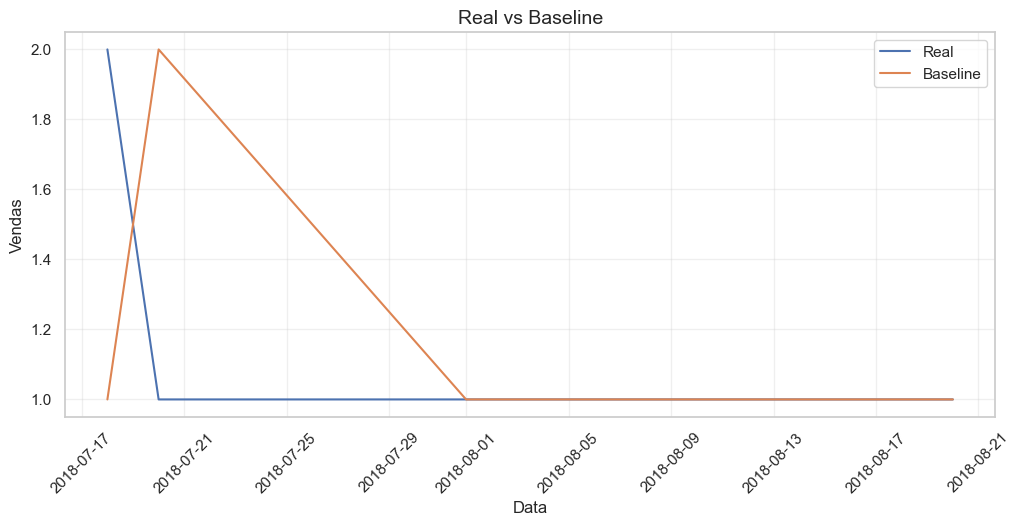

In [17]:
sample_product = df['product_id'].iloc[0]

df_sample = df[df['product_id'] == sample_product]

plt.figure(figsize=(12,5))

plt.plot(
    df_sample['date'],
    df_sample['sales'],
    label='Real'
)

plt.plot(
    df_sample['date'],
    df_sample['baseline_pred'],
    label='Baseline'
)

plt.title('Real vs Baseline')
plt.xlabel('Data')
plt.ylabel('Vendas')

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## 12. Distribuição dos Erros

In [18]:
df['error'] = df['sales'] - df['baseline_pred']

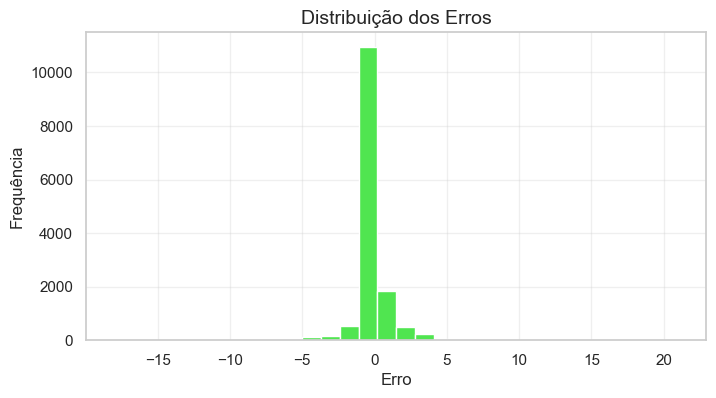

In [19]:
plt.figure(figsize=(8,4))

plt.hist(
    df['error'],
    bins=30,
    color=PRIMARY_COLOR
)

plt.title('Distribuição dos Erros')
plt.xlabel('Erro')
plt.ylabel('Frequência')

plt.grid(alpha=0.3)

plt.show()

## 13. Insights do Baseline

💡 Insights

O modelo baseline apresentou bom desempenho inicial, indicando que o comportamento recente da demanda possui forte capacidade preditiva.

Isso sugere que:
- muitos produtos possuem baixa variabilidade temporal
- a demanda apresenta certa estabilidade
- padrões recentes influenciam fortemente o comportamento futuro

Entretanto, o baseline possui limitações importantes:
- não captura sazonalidade
- não considera tendência
- não incorpora fatores externos

Dessa forma, modelos mais avançados serão avaliados nas próximas etapas.

In [20]:
df.to_parquet('../data/processed/df_baseline.parquet')

## 14. Conclusão

O baseline estabeleceu uma referência inicial de desempenho para o problema de previsão de demanda.

A partir deste ponto, modelos mais sofisticados serão desenvolvidos e comparados com esta abordagem simples, permitindo avaliar ganhos reais de performance e impacto na tomada de decisão em estoque.